# Longitudinal trajectory classification — common notebook (adapter-driven)

One model-agnostic notebook for every longitudinal trajectory experiment. The
per-model logic lives in an **adapter** (`CLASSIFIER/adapters/`) selected by the
`ADAPTER` parameter (defaults to `MODEL`); the SHARED cells below call only the
six contract hooks plus `common/` utilities, so they are identical across models.

GELSTM / GEGRU and the GEC-MLP are covered by two adapters; FDR and GRU are config
flags (`use_fdr`, `rnn_type`), not separate notebooks. Driven by `run_experiment.py`
via `experiments.yaml`; also runnable standalone (interactive prompts preserved).

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour
# (interactive checkpoint/threshold prompts).
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                # adapter registry key; None -> defaults to MODEL
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # None -> interactive checkpoint picker
THRESHOLD_MODE = None         # None -> interactive prompt; else youden | best-f1 | fixed
FIXED_THRESHOLD = None        # required when THRESHOLD_MODE is fixed
WANDB_ENABLED = True          # W&B logging is on by default
OUTPUT_DIR = None             # defaults to a common-notebook checkpoints dir when standalone
RESOLVED_CONFIG = None        # merged hyperparameter dict (dataclass < json < hyperparams)
RUN_DIR = None                # set by the runner: where run_summary.json / artifacts go
RUN_NAME = None               # set by the runner: the W&B run name

In [2]:
# Parameters
EXPERIMENT_ID = "gec-trajectory-whole-brain"
MODE = "longitudinal"
MODEL = "GEC"
ADAPTER = "gec"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = "notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth"
THRESHOLD_MODE = "best-f1"
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/gec-trajectory-whole-brain"
RESOLVED_CONFIG = {"epochs": 80, "lr": 0.001, "batch_size": 32, "grad_clip": 1.0, "early_stopping_patience": 20, "use_scheduler": True, "seed": 42, "wandb_project": "ad-early-detection", "wandb_enabled": True, "threshold_mode": "youden", "fixed_threshold": 0.5, "lr_factor": 0.5, "lr_patience": 5, "lr_min": 1e-06, "max_visits": None, "mlp_hidden_layers": [256, 128, 64], "mlp_dropout": 0.4, "use_time_delta": True, "append_visit_mask": True, "learning_rate": 0.001, "n_folds": 5, "adjacency_k": 8, "file_variant": "z_transformed"}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gec-trajectory-whole-brain/runs/dainty-totem-7-eb1a07a3a-2026-06-21_01-07-28"
RUN_NAME = "dainty-totem-7-eb1a07a3a-2026-06-21_01-07-28"


## Pipeline overview

`set_seed` → load splits → `prepare_data` (HOOK) → `build_model` (HOOK) →
`run_kfold_cv` (drives `train_fold` HOOK) → `select_oof_threshold` → `save_run` →
test (`eval_split` HOOK) → ROC → `early_detection_table` (`truncate_to_n_visits`) →
`trajectory_frame` (`per_visit_probs`).

In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))

In [4]:
# reproducibility seeding — must run before datasets, samplers, or models.
from CLASSIFIER.common.seeding import (
    set_seed, make_rng, make_torch_generator, seed_worker,
)
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)

In [5]:
import json, os, copy, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import classification_report

# Shared, model-agnostic utilities (the lifted notebook logic — reuse, do not inline).
from common.checkpoints import select_gaae_checkpoint
from common.sanity import run_full_audit
from common import tracking
from common.provenance import region_from_data_root
from common.crossval import Bundle, run_kfold_cv, summarize_cv
from common.thresholds import select_oof_threshold
from common.plots import plot_oof_test_roc, plot_conversion_trajectories
from common.early_detection import early_detection_table, trajectory_frame
from common.run_artifacts import save_run, record_test_metrics
from adapters import get_adapter

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Configuration

In [7]:
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

# ── Paths ────────────────────────────────────────────────────────────────
WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohorts.csv')
SPLITS_DIR   = str(splits_dir('downstream'))
TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')

DATA_INFO = region_from_data_root(WB_DATA_ROOT)
REGION    = DATA_INFO['region']
print(f"Input data: region={DATA_INFO['region']}  atlas={DATA_INFO['atlas']}  ({DATA_INFO['dataset_dir']})")

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_gaae_whole_brain'),
]
if OUTPUT_DIR is None:
    OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_longitudinal_common')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# GAAE encoder config (must match the checkpoint).
CONFIG_PATH = model_root / 'configs' / 'gaae_delcode_whole_brain.json'

# Training hyperparameters come entirely from the runner (RESOLVED_CONFIG = dataclass
# defaults < config_path json < hyperparams). Standalone use without a config falls
# back to each adapter's typed defaults.
TRAIN_CONFIG = dict(RESOLVED_CONFIG) if RESOLVED_CONFIG else {}
N_FOLDS = int(TRAIN_CONFIG.get('n_folds', 5))
print('Config set.  TRAIN_CONFIG keys:', sorted(TRAIN_CONFIG))

Input data: region=wholebrain  atlas=sch200  (__fc_wholebrain_sch200_flat__)
Config set.  TRAIN_CONFIG keys: ['adjacency_k', 'append_visit_mask', 'batch_size', 'early_stopping_patience', 'epochs', 'file_variant', 'fixed_threshold', 'grad_clip', 'learning_rate', 'lr', 'lr_factor', 'lr_min', 'lr_patience', 'max_visits', 'mlp_dropout', 'mlp_hidden_layers', 'n_folds', 'seed', 'threshold_mode', 'use_scheduler', 'use_time_delta', 'wandb_enabled', 'wandb_project']


In [8]:
# split-hygiene audit — hard-fails if any subject crosses splits.
_ = run_full_audit(split_csv_paths('downstream'))

[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


## Select GAAE Checkpoint

In [9]:
# Shared helper: resolves GAAE_CHECKPOINT_PATH headlessly under the runner, or
# prompts for an index interactively.
if GAAE_CHECKPOINT_PATH is None and RUN_DIR is not None:
    raise ValueError(
        "GAAE_CHECKPOINT_PATH is required under the experiment runner. "
        "Set 'checkpoint_path:' on this entry in experiments.yaml."
    )
GAAE_RUN_NAME, GAAE_CKPT_PATH, GAAE_RUN_DIR = select_gaae_checkpoint(
    CHECKPOINT_SEARCH_DIRS, checkpoint_path=GAAE_CHECKPOINT_PATH,
)
GAAE_CKPT_PATH = str(GAAE_CKPT_PATH)
print(f'Selected GAAE: {GAAE_RUN_NAME}')

Selected (non-interactive): ethereal-planet-16_2026-06-10_12-31-05
Selected GAAE: ethereal-planet-16_2026-06-10_12-31-05


In [10]:
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f: hp = json.load(f)
    print('GAAE config:', hp)
else:
    hp = dict(latent_dim=64, hidden_dim=128, num_heads=2, cond_dim=2, dropout=0.3,
              adjacency_k=8, file_variant='z_transformed')
    print('GAAE config not found — using defaults.')

GAAE config: {'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001, 'adj_loss_weight': 0.2, 'epochs': 500, 'early_stopping_patience': 25, 'latent_dim': 64, 'hidden_dim': 128, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'}


## Model adapter

`get_adapter(ADAPTER or MODEL)` resolves the per-model adapter (instantiated with the
GAAE checkpoint, GAAE config, merged training config, and data paths). Its six bound
methods are aliased to the contract-hook names the SHARED cells call.

In [11]:
adapter = get_adapter(ADAPTER or MODEL)(
    gaae_ckpt_path=GAAE_CKPT_PATH, gaae_hp=hp, train_config=TRAIN_CONFIG,
    data_root=WB_DATA_ROOT, cohorts_csv=COHORTS_CSV, device=device, rng=rng,
)
print(f'Adapter: {type(adapter).__name__}  (key={ADAPTER or MODEL})  model_tag={adapter.model_tag}')

# Bind the six contract hooks so every SHARED cell below stays model-agnostic.
build_model          = adapter.build_model
prepare_data         = adapter.prepare_data
train_fold           = adapter.train_fold
eval_split           = adapter.eval_split
truncate_to_n_visits = adapter.truncate_to_n_visits
per_visit_probs      = adapter.per_visit_probs

Adapter: GECAdapter  (key=gec)  model_tag=gec


In [12]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# CV pool = train + val; test held out.
cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print('CV pool:', cv_pool_df['diagnosis'].value_counts().to_dict())
print('Test:   ', test_df['diagnosis'].value_counts().to_dict())

CV pool: {'mci': 79, 'converter': 54}
Test:    {'mci': 20, 'converter': 14}


In [13]:
# HOOK calls: encode each split into a Bundle (CV pool first — it locks the model's
# input width for GEC), then smoke-test the model.
CV_BUNDLE   = prepare_data(cv_pool_df)
TEST_BUNDLE = prepare_data(test_df)
print(f'CV subjects: {len(CV_BUNDLE)}  Test subjects: {len(TEST_BUNDLE)}')

_ = build_model()   # smoke-test arch construction

LongitudinalSubjectDataset[v2]: 133 subjects (54 converter, 79 stable MCI)
  Scans per subject: min=1  max=6  mean=3.0


GEC: MAX_VISITS=6  k=64  feat_dim=396
LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9


CV subjects: 133  Test subjects: 34
LongitudinalMLP: input=396  params=143,745


## 5-Fold Stratified Subject-Level Cross-Validation

In [14]:
# Open the W&B run, then run the shared CV loop driven by the train_fold hook.
_wb_exp = {'id': EXPERIMENT_ID or 'longitudinal-common', 'mode': MODE or 'longitudinal',
           'model': MODEL or 'GELSTM', 'dataset': DATASET or REGION,
           'seed': SEED, 'wandb': WANDB_ENABLED}
WANDB_RUN = tracking.init_run(_wb_exp, {**(RESOLVED_CONFIG or {}), 'REGION': REGION,
                                        'adapter': ADAPTER or MODEL})

CV = run_kfold_cv(
    CV_BUNDLE, train_fold, TRAIN_CONFIG,
    n_folds=N_FOLDS, rng=rng, device=device,
    log_fn=lambda d: tracking.log_metrics(WANDB_RUN, d),
)

CV_RESULTS             = CV.cv_results
OOF_PROBS, OOF_TARGETS = CV.oof_probs, CV.oof_targets
OOF_SIDS               = CV.oof_sids
BEST_MODEL_STATE       = CV.best_model_state
BEST_FOLD              = CV.best_fold
BEST_VAL_AUC           = CV.best_val_auc

Fold 1/5  train=106  val=27


  AUC=0.9716  sens=0.909  spec=1.000  F1=0.952
Fold 2/5  train=106  val=27


  AUC=0.8807  sens=0.818  spec=0.938  F1=0.857
Fold 3/5  train=106  val=27


  AUC=0.9659  sens=1.000  spec=0.875  F1=0.917
Fold 4/5  train=107  val=26


  AUC=0.9875  sens=0.900  spec=1.000  F1=0.947
Fold 5/5  train=107  val=26


  AUC=0.9273  sens=1.000  spec=0.733  F1=0.846

Best fold: 4  CV AUC=0.9875
Youden thr=0.9027  OOF-F1 thr=0.6536


## Cross-Validation Summary

In [15]:
summarize_cv(CV_RESULTS)

Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.9466     0.0384     0.8807     0.9875
val_sensitivity          0.9255     0.0686     0.8182     1.0000
val_specificity          0.9092     0.0994     0.7333     1.0000
val_f1                   0.9039     0.0446     0.8462     0.9524


In [16]:
# Resolve the active threshold from pooled out-of-fold predictions (Best-F1 default).
# Validation/OOF only — never the test set (see .claude/rules/evaluation.md).
ACTIVE_THRESHOLD, THRESHOLD_METHOD = select_oof_threshold(
    OOF_TARGETS, OOF_PROBS,
    threshold_mode=THRESHOLD_MODE, fixed_threshold=FIXED_THRESHOLD,
    runner_active=RUN_DIR is not None,
)

OOF threshold options:
  [1] Best-F1 (default) thr=0.6536  sens=0.815  spec=0.873  F1=0.815
  [2] Youden            thr=0.6536  sens=0.815  spec=0.873  F1=0.815
Using oof_f1 threshold: 0.6536


## Save Best Model

In [17]:
# Adapter supplies the model-specific descriptors; the shared save_run does the rest.
MODEL_CONFIG = adapter.model_config()
SOURCE_FILES = adapter.source_files()
DATASET_INFO = {**DATA_INFO, 'train_csv': TRAIN_CSV, 'val_csv': VAL_CSV,
                'test_csv': TEST_CSV, 'n_folds': N_FOLDS}

RUN_NAME, RUN_DIR = save_run(
    output_dir=OUTPUT_DIR, run_dir=RUN_DIR, run_name=RUN_NAME,
    model_state=adapter.model_state_for_save(BEST_MODEL_STATE),
    model_config=MODEL_CONFIG, training_config=TRAIN_CONFIG,
    data_info=DATA_INFO, dataset_info=DATASET_INFO, rng=rng,
    best_val_auc=BEST_VAL_AUC, active_threshold=ACTIVE_THRESHOLD, threshold_method=THRESHOLD_METHOD,
    best_fold=BEST_FOLD, cv_results=CV_RESULTS,
    gaae_checkpoint=GAAE_CKPT_PATH, gaae_run_name=GAAE_RUN_NAME,
    source_files=SOURCE_FILES, n_folds=N_FOLDS, model_tag=adapter.model_tag,
)

# Model-specific side artifacts (e.g. dim_filter.npy / scaler.pkl for the GEC-MLP)
# so the comparison/dashboard loaders keep working.
adapter.extra_artifacts(RUN_DIR, BEST_MODEL_STATE)
print(f'Saved to {RUN_DIR}')

try:
    tracking.log_metrics(WANDB_RUN, {'cv_best_val_auc': float(BEST_VAL_AUC),
                                     'active_threshold': float(ACTIVE_THRESHOLD)})
except NameError:
    pass

Saved to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gec-trajectory-whole-brain/runs/dainty-totem-7-eb1a07a3a-2026-06-21_01-07-28


## Test-Set Evaluation

In [18]:
# HOOK: score the held-out test set at the val-derived threshold (no test leakage).
TEST_METRICS = eval_split(BEST_MODEL_STATE, TEST_BUNDLE, ACTIVE_THRESHOLD, device=device)

print('Test-Set Results')
print('=' * 40)
print(f"AUC:         {TEST_METRICS['auc']:.4f}")
print(f"Sensitivity: {TEST_METRICS['sensitivity']:.4f}")
print(f"Specificity: {TEST_METRICS['specificity']:.4f}")
print(f"F1:          {TEST_METRICS['f1']:.4f}")
print(f"Threshold:   {ACTIVE_THRESHOLD:.4f}  ({THRESHOLD_METHOD})")
print()
print(classification_report(TEST_METRICS['targets'],
                            (np.asarray(TEST_METRICS['probs']) >= ACTIVE_THRESHOLD).astype(int),
                            target_names=['stable_mci', 'converter']))

record_test_metrics(RUN_DIR, TEST_METRICS, threshold=ACTIVE_THRESHOLD, threshold_method=THRESHOLD_METHOD)
print(f"Test metrics saved to {RUN_DIR / 'run_summary.json'}")

try:
    tracking.log_metrics(WANDB_RUN, {'test_auc': float(TEST_METRICS['auc']), 'test_f1': float(TEST_METRICS['f1']),
                                     'test_sensitivity': float(TEST_METRICS['sensitivity']),
                                     'test_specificity': float(TEST_METRICS['specificity'])})
    tracking.finish_run(WANDB_RUN)
except NameError:
    pass

Test-Set Results
AUC:         0.9643
Sensitivity: 0.8571
Specificity: 0.8500
F1:          0.8276
Threshold:   0.6536  (oof_f1)

              precision    recall  f1-score   support

  stable_mci       0.89      0.85      0.87        20
   converter       0.80      0.86      0.83        14

    accuracy                           0.85        34
   macro avg       0.85      0.85      0.85        34
weighted avg       0.86      0.85      0.85        34

Test metrics saved to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/gec-trajectory-whole-brain/runs/dainty-totem-7-eb1a07a3a-2026-06-21_01-07-28/run_summary.json


## ROC Curves

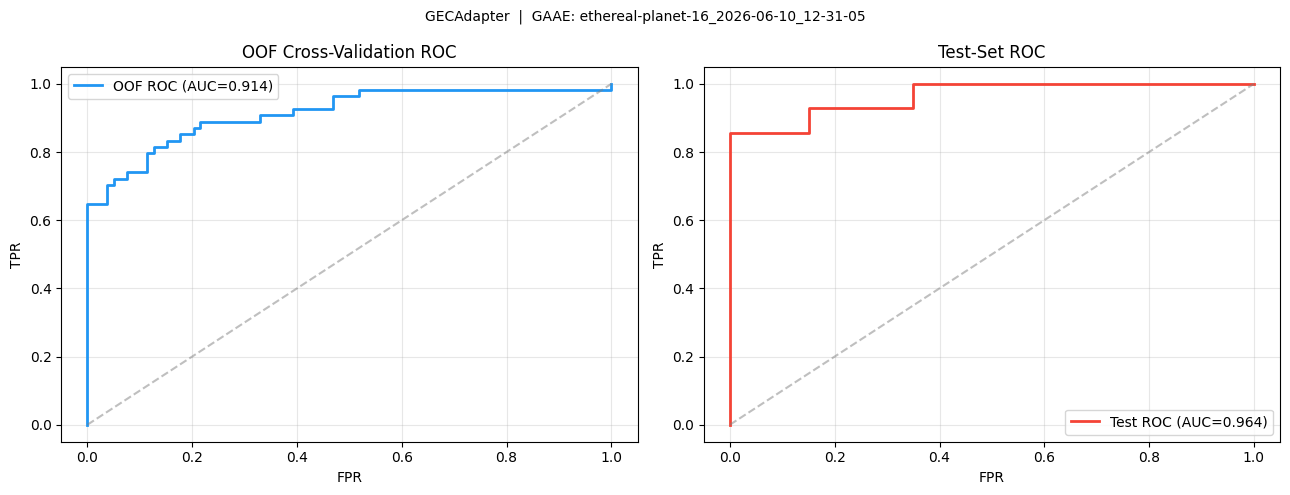

In [19]:
fig = plot_oof_test_roc(
    OOF_TARGETS, OOF_PROBS, TEST_METRICS['targets'], TEST_METRICS['probs'],
    title=f'{type(adapter).__name__}  |  GAAE: {GAAE_RUN_NAME}',
)
plt.show()

## Early-Detection Curve: AUC vs. Number of Visits Used

Shared `early_detection_table`: for each N it restricts every test subject with `T >= N`
visits to their first N (via `truncate_to_n_visits`) and re-scores with `eval_split`.
Rows with fewer than 4 subjects or a single class are skipped. `N=1` = single-scan.

In [20]:
ED_ROWS = early_detection_table(
    TEST_BUNDLE, eval_split, truncate_to_n_visits,
    BEST_MODEL_STATE, ACTIVE_THRESHOLD, device=device,
)


Visits    N      AUC     Sens     Spec
----------------------------------------
     1   34   0.5643    0.143    0.850
     2   28   0.9286    0.857    0.714
     3   18   0.9500    0.900    1.000
     4   12   0.9143    0.857    1.000


## Conversion Probability Trajectories

Shared `trajectory_frame` builds per-visit `P(converter)` for each test subject with
>= 2 visits (via `per_visit_probs`); `plot_conversion_trajectories` renders the panels.

Trajectory data: 28 subjects


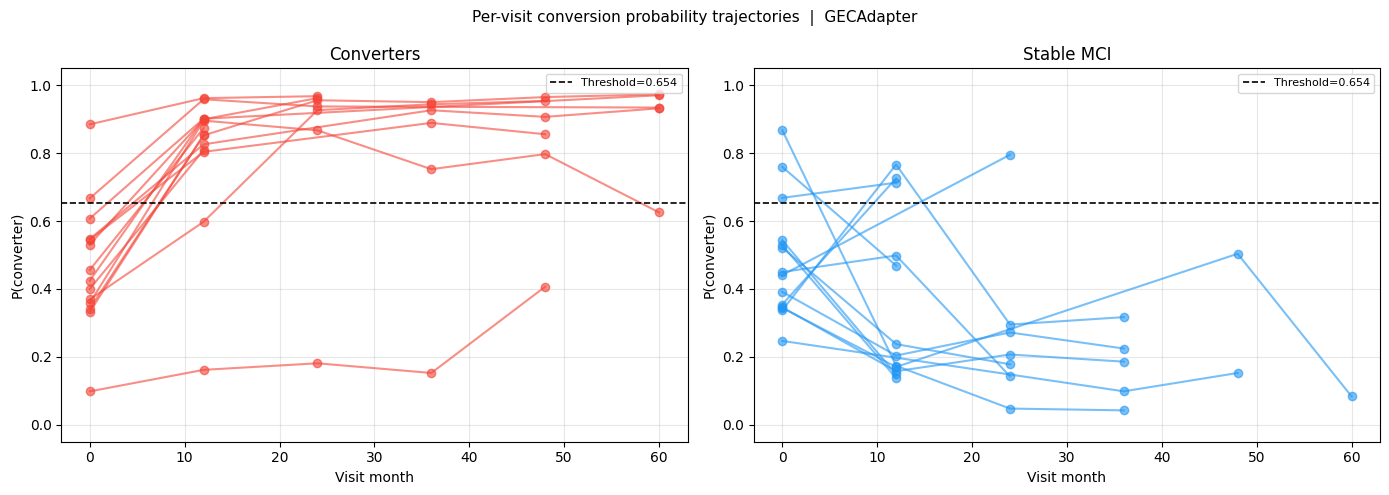

In [21]:
TRAJ_DF = trajectory_frame(TEST_BUNDLE, per_visit_probs, BEST_MODEL_STATE, device=device)
print(f"Trajectory data: {TRAJ_DF['pid'].nunique()} subjects")
fig = plot_conversion_trajectories(
    TRAJ_DF, ACTIVE_THRESHOLD,
    title=f'Per-visit conversion probability trajectories  |  {type(adapter).__name__}',
)
plt.show()